# Garbage Classification Deep Learning Model

This notebook trains a deep learning image classifier on the `garbage_classification` dataset folder. The dataset should be arranged with one subfolder per class.

## 1. Install Requirements

Run this cell once if TensorFlow or the helper libraries are not installed.

In [2]:
# Uncomment and run if needed
# !pip install tensorflow numpy matplotlib pillow

## 2. Import Libraries

In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 3. Configure Paths and Training Settings

In [4]:
DATA_DIR = Path('garbage_classification')
OUTPUT_DIR = Path('models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 12
FINE_TUNE_EPOCHS = 5
VALIDATION_SPLIT = 0.2
SEED = 42

if not DATA_DIR.exists():
    raise FileNotFoundError(f'Dataset folder not found: {DATA_DIR.resolve()}')

## 4. Inspect Dataset

In [5]:
class_counts = {}
for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        image_count = sum(
            1 for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        )
        class_counts[class_dir.name] = image_count

class_counts

{'battery': 945,
 'biological': 985,
 'brown-glass': 607,
 'cardboard': 891,
 'clothes': 5325,
 'green-glass': 629,
 'metal': 769,
 'paper': 1050,
 'plastic': 865,
 'shoes': 1977,
 'testing': 5,
 'trash': 697,
 'white-glass': 775}

## 5. Load Train and Validation Datasets

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

class_names = train_ds.class_names
num_classes = len(class_names)

print('Classes:', class_names)
print('Number of classes:', num_classes)

Found 15518 files belonging to 13 classes.
Using 12415 files for training.
Found 15518 files belonging to 13 classes.
Using 3103 files for validation.
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'testing', 'trash', 'white-glass']
Number of classes: 13


## 6. Visualize Sample Images

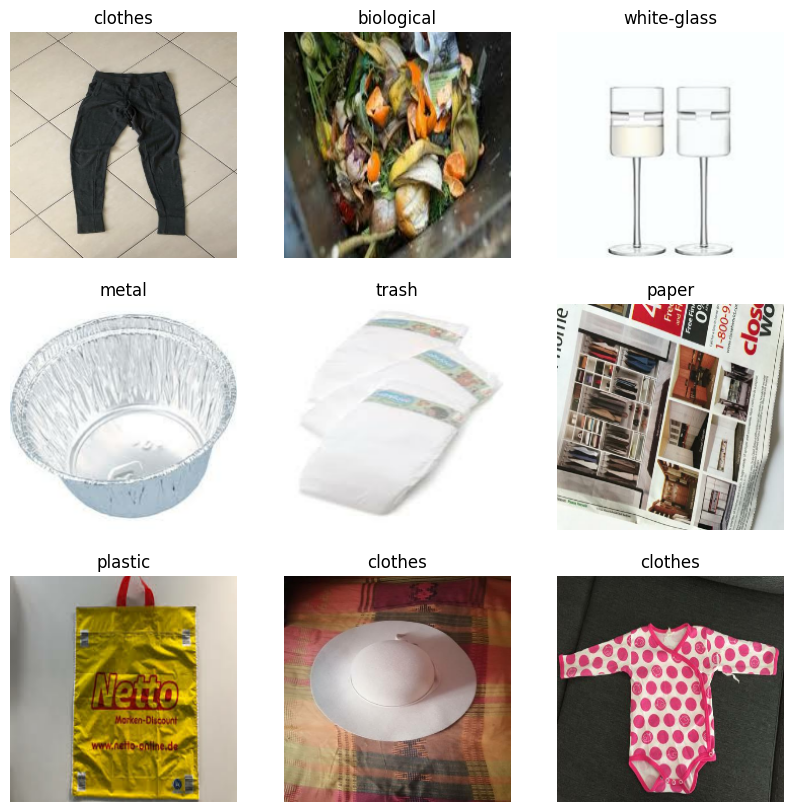

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.show()

## 7. Prepare Class Weights

The dataset is imbalanced, especially because the `clothes` class has many more images. Class weights help the model pay fairer attention to smaller classes.

In [8]:
total_images = sum(class_counts.values())
class_weights = {
    index: total_images / (num_classes * max(class_counts[class_name], 1))
    for index, class_name in enumerate(class_names)
}

class_weights

{0: 1.2633292633292634,
 1: 1.2120265521280749,
 2: 1.9667976175389685,
 3: 1.3398946732280066,
 4: 0.22419646081617914,
 5: 1.898006603888957,
 6: 1.5524657397219166,
 7: 1.136996336996337,
 8: 1.380168963983993,
 9: 0.6038675537916812,
 10: 238.76923076923077,
 11: 1.7128352278997903,
 12: 1.5404466501240694}

## 8. Improve Input Pipeline

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

## 9. Build Transfer Learning Model

In [10]:
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.12),
        tf.keras.layers.RandomContrast(0.1),
    ],
    name='augmentation',
)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 13)             │        16,653 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,274,637 (8.68 MB)

 Trainable params: 16,653 (65.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Train the Classification Head

In [ ]:
checkpoint_path = OUTPUT_DIR / 'best_garbage_classifier.keras'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/12
  9/388 ━━━━━━━━━━━━━━━━━━━━ 6:43 1s/step - accuracy: 0.0904 - loss: 2.6651   

## 11. Fine Tune the Last MobileNetV2 Layers

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS + FINE_TUNE_EPOCHS,
    initial_epoch=len(history.history['loss']),
    class_weight=class_weights,
    callbacks=callbacks,
)

for key, values in history_fine.history.items():
    history.history.setdefault(key, []).extend(values)

Epoch 13/17
388/388 ━━━━━━━━━━━━━━━━━━━━ 569s 1s/step - accuracy: 0.8924 - loss: 0.3869 - val_accuracy: 0.9468 - val_loss: 0.1720 - learning_rate: 1.0000e-05
Epoch 14/17
388/388 ━━━━━━━━━━━━━━━━━━━━ 533s 1s/step - accuracy: 0.9149 - loss: 0.2882 - val_accuracy: 0.9452 - val_loss: 0.1726 - learning_rate: 1.0000e-05
Epoch 15/17
388/388 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.9245 - loss: 0.2487 - val_accuracy: 0.9459 - val_loss: 0.1766 - learning_rate: 3.0000e-06
Epoch 16/17
388/388 ━━━━━━━━━━━━━━━━━━━━ 526s 1s/step - accuracy: 0.9271 - loss: 0.2426 - val_accuracy: 0.9449 - val_loss: 0.1786 - learning_rate: 3.0000e-06


## 12. Evaluate the Model

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f'Validation accuracy: {val_accuracy:.4f}')
print(f'Validation loss: {val_loss:.4f}')

97/97 ━━━━━━━━━━━━━━━━━━━━ 69s 712ms/step - accuracy: 0.9468 - loss: 0.1720
Validation accuracy: 0.9468
Validation loss: 0.1720


## 13. Plot Training History

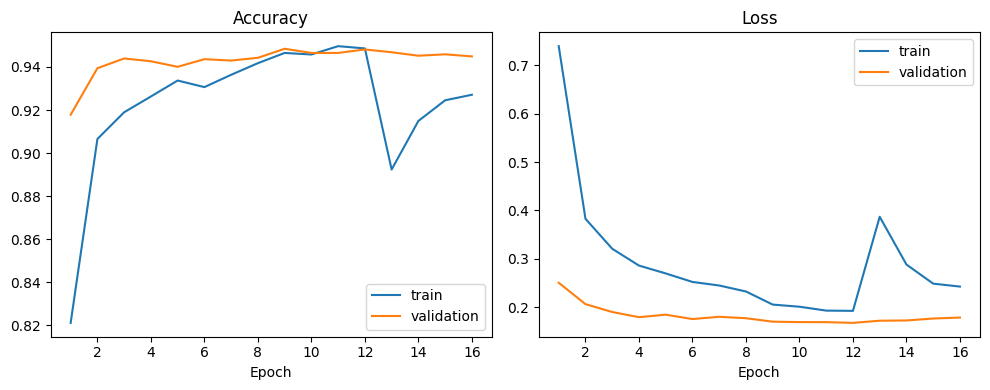

In [ ]:
metrics = history.history
epochs = range(1, len(metrics['loss']) + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, metrics['accuracy'], label='train')
plt.plot(epochs, metrics['val_accuracy'], label='validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, metrics['loss'], label='train')
plt.plot(epochs, metrics['val_loss'], label='validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150)
plt.show()

## 14. Save Model and Metadata

In [ ]:
final_model_path = OUTPUT_DIR / 'garbage_classifier_final.keras'
model.save(final_model_path)

metadata = {
    'class_names': class_names,
    'image_size': list(IMAGE_SIZE),
    'class_counts': class_counts,
    'class_weights': class_weights,
    'validation_accuracy': float(val_accuracy),
    'validation_loss': float(val_loss),
}

(OUTPUT_DIR / 'metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved best model to:', checkpoint_path)
print('Saved final model to:', final_model_path)
print('Saved metadata to:', OUTPUT_DIR / 'metadata.json')

Saved best model to: models\best_garbage_classifier.keras
Saved final model to: models\garbage_classifier_final.keras
Saved metadata to: models\metadata.json


## 15. Predict One Image

In [ ]:
def predict_image(image_path, top_k=3, model_path=checkpoint_path):
    loaded_model = tf.keras.models.load_model(model_path)
    image = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    array = tf.keras.utils.img_to_array(image)
    batch = np.expand_dims(array, axis=0)

    probabilities = loaded_model.predict(batch, verbose=0)[0]
    top_indices = probabilities.argsort()[-top_k:][::-1]

    plt.imshow(image)
    plt.axis('off')
    plt.show()

    for index in top_indices:
        print(f'{class_names[index]}: {probabilities[index]:.4f}')

In [ ]:
# Change this path to any image you want to test
# Change this path to any image you want to test
predict_image(Path("garbage_classification") / "testing" / "pen.jpeg")

NameError: name 'predict_image' is not defined